# Generative Naive Bayes — Distribution Fitting

Fit parametric distributions to each feature conditioned on `Problem_SKU`, then use those as a Naive Bayes generative classifier. Well-calibrated probabilities support reliable high-precision thresholding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, precision_recall_curve,
)

path = r"..\Data\SyntheticData\2026_03_31_01_52_14\std_synthetic_data_2026_03_31_01_52_14.csv"
df = pd.read_csv(path)
target = "Problem_SKU"

numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]

size_dummies = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)
binary_cols = list(size_dummies.columns) + ['Defect_In_Linked_Receive']
defect_linked_num = df['Defect_In_Linked_Receive'].astype(int)

X = pd.concat([df[numeric_features], size_dummies, defect_linked_num], axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Problem_SKU base rate: {y_test.mean():.3f}")

Train: (220000, 13)  Test: (55000, 13)
Problem_SKU base rate: 0.074


## 1. Distribution Fitting

For each numeric feature, fit several unbounded parametric distributions to the per-class training data.
KS statistic measures goodness-of-fit — lower is better. `skewnorm` and `t` capture asymmetry and heavy tails that `norm` misses.

In [2]:
CANDIDATES = {
    "norm":     st.norm,
    "t":        st.t,
    "laplace":  st.laplace,
    "logistic": st.logistic,
    "skewnorm": st.skewnorm,
}

rng = np.random.default_rng(42)

def fit_distributions(data, candidates=CANDIDATES, n_ks_samples=5000):
    """Fit each candidate; return list sorted by KS statistic ascending."""
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if len(data) > n_ks_samples:
        idx = rng.choice(len(data), n_ks_samples, replace=False)
        sample = data[idx]
    else:
        sample = data
    results = []
    for name, dist in candidates.items():
        try:
            params = dist.fit(data)
            ks_stat, ks_p = st.kstest(sample, dist.cdf, args=params)
            results.append({"dist": name, "params": params, "ks_stat": ks_stat, "ks_p": ks_p})
        except Exception:
            pass
    return sorted(results, key=lambda r: r["ks_stat"])


# Fit per feature per class
fit_results = {}
for col in numeric_features:
    fit_results[col] = {}
    for cls in [False, True]:
        data = X_train.loc[y_train == cls, col].dropna()
        fit_results[col][cls] = fit_distributions(data)

# Summary table
rows = []
for col in numeric_features:
    for cls in [False, True]:
        best = fit_results[col][cls][0]
        rows.append({
            "feature":   col.replace("_std", ""),
            "class":     cls,
            "best_dist": best["dist"],
            "ks_stat":   round(best["ks_stat"], 4),
            "ks_p":      round(best["ks_p"], 4),
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

                 feature  class best_dist  ks_stat   ks_p
Global_SKU_Defect_Rate_%  False  skewnorm   0.0426 0.0000
Global_SKU_Defect_Rate_%   True  skewnorm   0.0451 0.0000
   ABS_Volume_Difference  False  skewnorm   0.0111 0.5629
   ABS_Volume_Difference   True  skewnorm   0.0531 0.0000
            Aisle_Hold_%  False      norm   0.2278 0.0000
            Aisle_Hold_%   True  skewnorm   0.1239 0.0000
           #_Pick_Events  False  skewnorm   0.0528 0.0000
           #_Pick_Events   True  skewnorm   0.0461 0.0000
 #_Pick_Events_In_Clique  False  skewnorm   0.0275 0.0010
 #_Pick_Events_In_Clique   True  skewnorm   0.0311 0.0001
                 #_Picks  False  skewnorm   0.0305 0.0002
                 #_Picks   True  skewnorm   0.0255 0.0030
       #_Picks_In_Clique  False         t   0.0741 0.0000
       #_Picks_In_Clique   True  skewnorm   0.1308 0.0000
             Time_In_Loc  False  skewnorm   0.0318 0.0001
             Time_In_Loc   True  skewnorm   0.0278 0.0009
      Current_

## 2. Visualize Fitted Distributions

Top 4 features by DT importance. Each column is one class. Top 3 fits overlaid on the empirical histogram — look for separation between True/False panels.

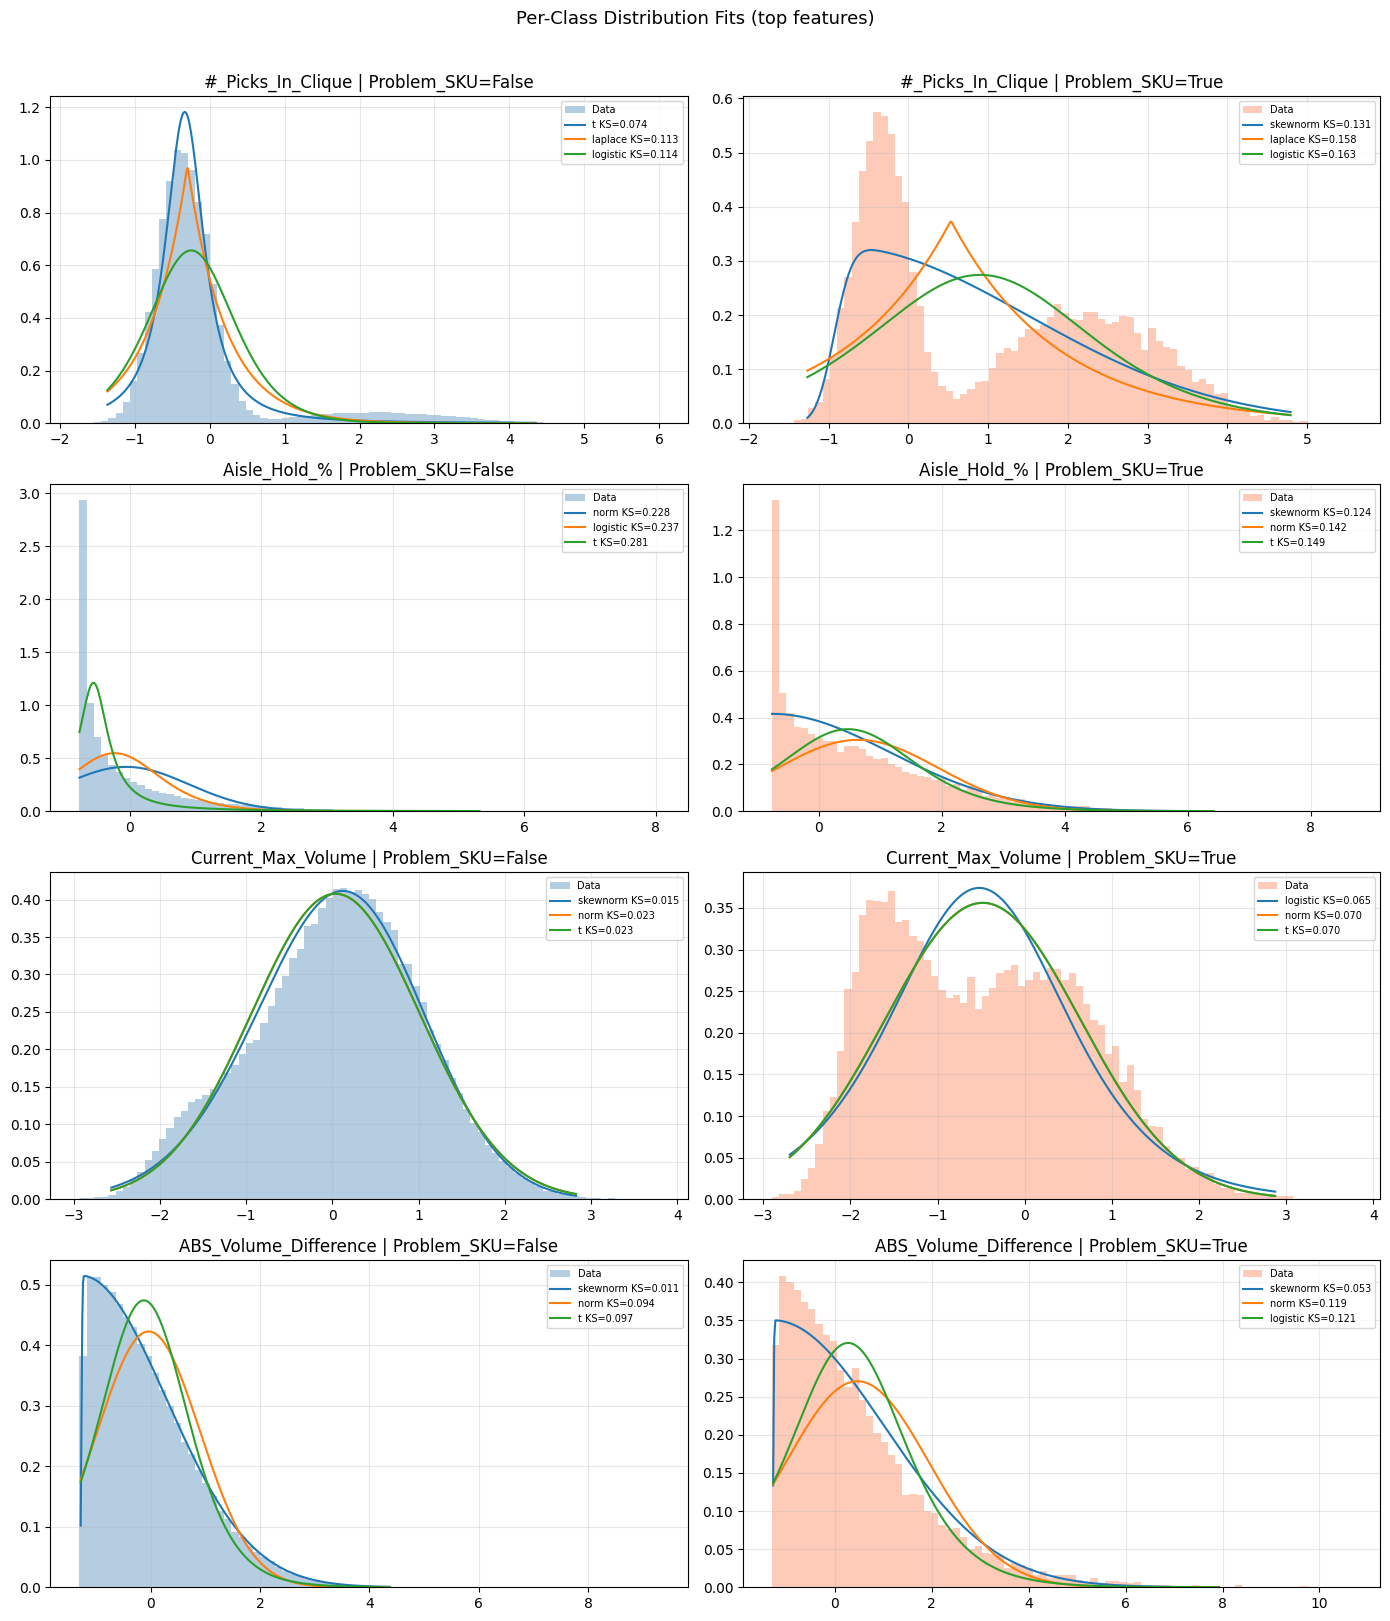

In [3]:
top_features = [
    "#_Picks_In_Clique_std",
    "Aisle_Hold_%_std",
    "Current_Max_Volume_std",
    "ABS_Volume_Difference_std",
]

fig, axes = plt.subplots(len(top_features), 2, figsize=(14, 4 * len(top_features)))

for row_idx, col in enumerate(top_features):
    for col_idx, cls in enumerate([False, True]):
        ax = axes[row_idx, col_idx]
        data = X_train.loc[y_train == cls, col].dropna()
        color = "steelblue" if not cls else "coral"
        ax.hist(data, bins=80, density=True, alpha=0.4, color=color, label="Data")

        lo, hi = data.quantile(0.001), data.quantile(0.999)
        x = np.linspace(lo, hi, 400)
        for entry in fit_results[col][cls][:3]:
            dist_obj = CANDIDATES[entry["dist"]]
            try:
                ax.plot(x, dist_obj.pdf(x, *entry["params"]),
                        label=f"{entry['dist']} KS={entry['ks_stat']:.3f}")
            except Exception:
                pass

        ax.set_title(f"{col.replace('_std', '')} | Problem_SKU={cls}")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle("Per-Class Distribution Fits (top features)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Generative Naive Bayes

For each feature, use the best-fitted distribution to compute `log P(x | class)`. Sum across features (the naive independence assumption), add the log class prior, then normalize to get a posterior probability.

Binary features (storage size dummies, defect flag) use empirical Bernoulli probabilities per class.

In [4]:
class GenerativeNB:
    """Naive Bayes with per-feature, per-class fitted parametric distributions."""

    def __init__(self, candidates=CANDIDATES):
        self.candidates = candidates

    def fit(self, X, y, numeric_cols, binary_cols):
        self.numeric_cols_ = numeric_cols
        self.binary_cols_  = binary_cols
        self.classes_      = sorted(y.unique())
        n_total = len(y)

        self.fitted_       = {}   # {cls: {col: (dist_obj, params)}}
        self.class_prior_  = {}   # {cls: log_prior}
        self.binary_probs_ = {}   # {(col, cls): P(col=1|cls)}

        for cls in self.classes_:
            mask = y == cls
            self.class_prior_[cls] = np.log(mask.sum() / n_total)
            self.fitted_[cls] = {}

            for col in numeric_cols:
                data = X.loc[mask, col].dropna()
                best = fit_distributions(data, self.candidates)[0]
                self.fitted_[cls][col] = (self.candidates[best["dist"]], best["params"])

            for col in binary_cols:
                p = X.loc[mask, col].mean()
                self.binary_probs_[(col, cls)] = np.clip(p, 1e-6, 1 - 1e-6)

        return self

    def _log_likelihood(self, X, cls):
        lp = np.full(len(X), self.class_prior_[cls])

        for col in self.numeric_cols_:
            dist_obj, params = self.fitted_[cls][col]
            vals = X[col].values
            with np.errstate(divide='ignore', invalid='ignore'):
                ll = dist_obj.logpdf(vals, *params)
            lp += np.clip(ll, -50, 0)   # guard against extreme underflow

        for col in self.binary_cols_:
            p    = self.binary_probs_[(col, cls)]
            vals = X[col].values
            lp  += vals * np.log(p) + (1 - vals) * np.log(1 - p)

        return lp

    def predict_proba(self, X):
        log_probs = np.column_stack([
            self._log_likelihood(X, cls) for cls in self.classes_
        ])
        log_probs -= log_probs.max(axis=1, keepdims=True)   # numerical stability
        probs = np.exp(log_probs)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X, threshold=0.5):
        pos_idx = self.classes_.index(True)
        return (self.predict_proba(X)[:, pos_idx] >= threshold).astype(int)


print("Fitting GenerativeNB (fits one distribution per feature per class)...")
gnb = GenerativeNB()
gnb.fit(X_train, y_train, numeric_features, binary_cols)
print("Done.\n")

pos_idx      = gnb.classes_.index(True)
y_proba_gnb  = gnb.predict_proba(X_test)[:, pos_idx]
y_pred_gnb   = gnb.predict(X_test)

print("Generative NB (threshold=0.5)")
print(classification_report(y_test, y_pred_gnb, digits=3))
print(f"ROC AUC:           {roc_auc_score(y_test, y_proba_gnb):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_proba_gnb):.4f}")

Fitting GenerativeNB (fits one distribution per feature per class)...
Done.

Generative NB (threshold=0.5)
              precision    recall  f1-score   support

       False      0.956     0.945     0.951     50951
        True      0.397     0.452     0.423      4049

    accuracy                          0.909     55000
   macro avg      0.676     0.699     0.687     55000
weighted avg      0.915     0.909     0.912     55000

ROC AUC:           0.8379
Average Precision: 0.3613


## 4. Baseline: sklearn GaussianNB

sklearn assumes Normal for every feature regardless of the true distribution. Comparing AUC and Average Precision shows how much the distribution fitting actually helps.

In [5]:
gnb_sk = GaussianNB()
gnb_sk.fit(X_train, y_train)
y_proba_sk = gnb_sk.predict_proba(X_test)[:, 1]
y_pred_sk  = gnb_sk.predict(X_test)

print("sklearn GaussianNB (all-Normal baseline)")
print(classification_report(y_test, y_pred_sk, digits=3))
print(f"ROC AUC:           {roc_auc_score(y_test, y_proba_sk):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_proba_sk):.4f}")

sklearn GaussianNB (all-Normal baseline)
              precision    recall  f1-score   support

       False      0.954     0.917     0.935     50951
        True      0.296     0.442     0.355      4049

    accuracy                          0.882     55000
   macro avg      0.625     0.679     0.645     55000
weighted avg      0.905     0.882     0.892     55000

ROC AUC:           0.8330
Average Precision: 0.3401


## 5. Threshold Sweep — Precision Targets

For each precision floor, find the threshold that catches the most true Problem SKUs while staying above that floor.


Generative NB
 Prec Target  Threshold   Recall       F1    Flagged   of 4049 True
--------------------------------------------------------------------
        0.70        N/A
        0.75        N/A
        0.80        N/A
        0.85        N/A
        0.90        N/A
        0.95        N/A

GaussianNB (sklearn)
 Prec Target  Threshold   Recall       F1    Flagged   of 4049 True
--------------------------------------------------------------------
        0.70        N/A
        0.75        N/A
        0.80        N/A
        0.85        N/A
        0.90        N/A
        0.95        N/A


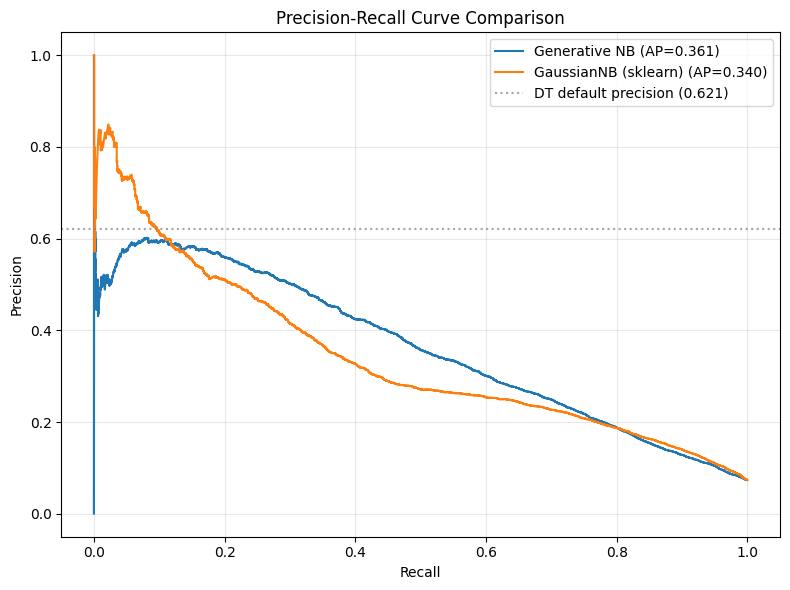

In [6]:
def threshold_sweep(y_true, y_proba):
    thresholds = np.arange(0.10, 0.96, 0.01)
    precisions, recalls, f1s, n_flagged = [], [], [], []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        flagged  = y_pred_t.sum()
        if flagged == 0:
            precisions.append(np.nan)
            recalls.append(0.0)
            f1s.append(0.0)
        else:
            precisions.append(precision_score(y_true, y_pred_t, zero_division=0))
            recalls.append(recall_score(y_true, y_pred_t, zero_division=0))
            f1s.append(f1_score(y_true, y_pred_t, zero_division=0))
        n_flagged.append(flagged)
    return (
        np.array(precisions), np.array(recalls),
        np.array(f1s), np.array(n_flagged), thresholds
    )


n_true = int(y_test.sum())

for label, proba in [("Generative NB", y_proba_gnb), ("GaussianNB (sklearn)", y_proba_sk)]:
    prec, rec, f1, nf, thresholds = threshold_sweep(y_test, proba)
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'Prec Target':>12} {'Threshold':>10} {'Recall':>8} {'F1':>8} {'Flagged':>10} {f'of {n_true} True':>14}")
    print("-" * 68)
    for target in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
        mask = prec >= target
        if mask.any():
            best_idx = np.where(mask)[0][np.argmax(rec[mask])]
            t = thresholds[best_idx]
            r = rec[best_idx]
            f = f1[best_idx]
            nflag = nf[best_idx]
            caught = int(round(r * n_true))
            print(f"{target:>12.2f} {t:>10.2f} {r:>8.3f} {f:>8.3f} {nflag:>10,} {caught:>14,}")
        else:
            print(f"{target:>12.2f} {'N/A':>10}")

# Precision-Recall curve comparison
fig, ax = plt.subplots(figsize=(8, 6))
for label, proba in [("Generative NB", y_proba_gnb), ("GaussianNB (sklearn)", y_proba_sk)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f"{label} (AP={ap:.3f})")
ax.axhline(0.621, color="gray", linestyle=":", alpha=0.7,
           label="DT default precision (0.621)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Comparison")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()